# Notebook 05 – Advanced Analysis

**Goal:** group Italian municipalities by accident profile (clustering) and test whether the differences between groups are statistically significant.

**Data:** `Data/Processed/integrated_clean.csv`

**1. Prepare the data** 
* Load the integrated table and filter to 2023, matched municipalities with valid rates. The two features for clustering are `accidents_per_1000` (risk per inhabitant) and `accidents_per_km2` (spatial concentration of accidents).

In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import statsmodels.api as sm

df = pd.read_csv("Data/Processed/integrated_clean.csv", keep_default_na=False, na_values=[""])

df_2023 = df[
    (df["TIME_PERIOD"] == 2023) &
    (df["Comune"].notna()) &
    (df["accidents_per_1000"].notna()) &
    (df["accidents_per_km2"].notna())
].copy()

print("Municipalities for clustering:", len(df_2023)) 

Municipalities for clustering: 7892


**2. Scaling and optimal number of clusters** –
* The two features (`accidents_per_1000` and `accidents_per_km2`) are scaled to the same range with `StandardScaler` before clustering, so neither dominates. The elbow method plots the inertia for k = 1 to 10: the optimal k is where the curve bends (the "elbow").

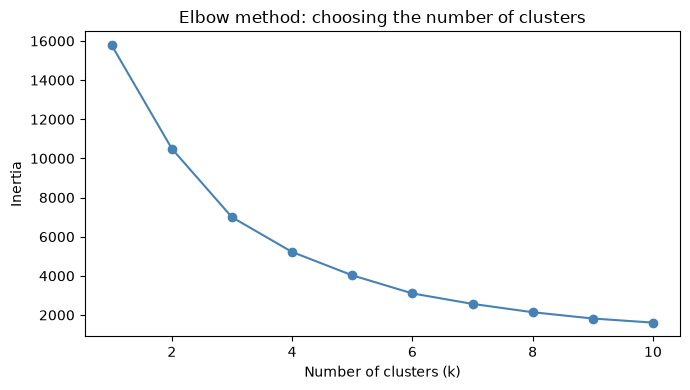

In [3]:
features = df_2023[["accidents_per_1000", "accidents_per_km2"]].copy()
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

inertia = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(features_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(range(1, 11), inertia, marker="o", color="steelblue")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow method: choosing the number of clusters")
plt.tight_layout()
plt.show()

**3. KMeans clustering (k=4)** 
* Four clusters chosen from the elbow plot. The centroids show the average accident rates for each group, back in the original scale. Most municipalities fall in the low-rate cluster.

In [4]:
km = KMeans(n_clusters=4, random_state=42, n_init=10)
df_2023["cluster"] = km.fit_predict(features_scaled)

print(df_2023["cluster"].value_counts().sort_index())

centroids = pd.DataFrame(
    scaler.inverse_transform(km.cluster_centers_),
    columns=["accidents_per_1000", "accidents_per_km2"]
).round(2)
centroids.index.name = "cluster"
print(centroids)

cluster
0    5138
1     154
2    2532
3      68
Name: count, dtype: int64
         accidents_per_1000  accidents_per_km2
cluster                                       
0                      0.83               0.17
1                      3.86               9.58
2                      3.24               0.98
3                     13.35               0.58


**4. Cluster visualization** 
* Scatter plot coloured by cluster. The axes are cut at 10 and 15 to zoom in on the bulk of municipalities: extreme outliers (e.g. Milano at 42 per km²) are outside the plot but visible in the centroid table.

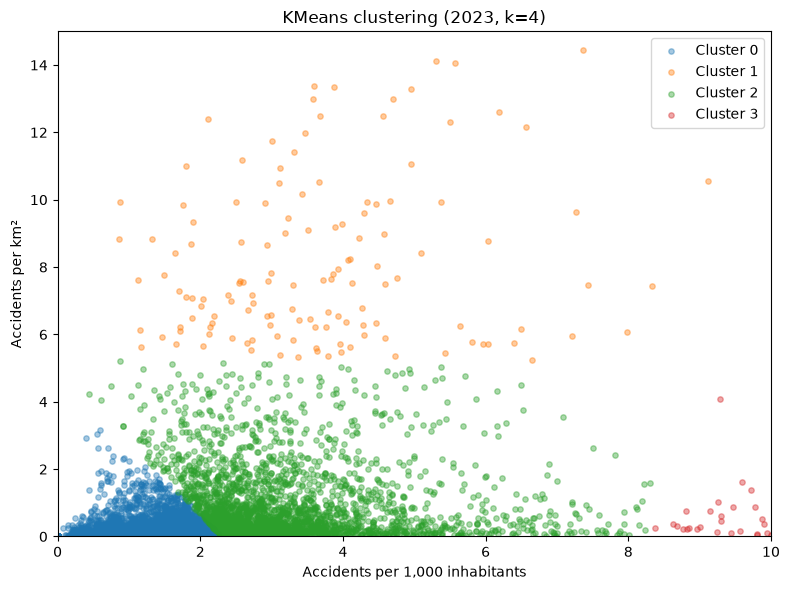

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))

for cluster_id, group in df_2023.groupby("cluster"):
    ax.scatter(
        group["accidents_per_1000"],
        group["accidents_per_km2"],
        alpha=0.4, s=15,
        label=f"Cluster {cluster_id}"
    )

ax.set_xlabel("Accidents per 1,000 inhabitants")
ax.set_ylabel("Accidents per km²")
ax.set_title("KMeans clustering (2023, k=4)")
ax.set_xlim(0, 10)      # zoom: cut extreme outliers on x
ax.set_ylim(0, 15)      # zoom: cut extreme outliers on y
ax.legend()
plt.tight_layout()
plt.show()

**5. Representative municipalities per cluster** 
* The 3 municipalities with the most accidents in each cluster. Confirms the cluster interpretation: cluster 0 = small low-risk towns; cluster 1 = dense urban areas (Milan belt); cluster 2 = medium cities; cluster 3 = high rate per inhabitant relative to population.

In [6]:
examples = []
for c in sorted(df_2023["cluster"].unique()):
    top3 = df_2023[df_2023["cluster"] == c].sort_values("accidents", ascending=False).head(3)
    top3 = top3[["cluster", "Comune", "accidents_per_1000", "accidents_per_km2", "Popolazione residente"]]
    examples.append(top3)

examples = pd.concat(examples, ignore_index=True)
print(examples.to_string())

    cluster              Comune  accidents_per_1000  accidents_per_km2  Popolazione residente
0         0              Andria            1.798450           0.431888                  96750
1         0            Altamura            2.023859           0.329184                  70163
2         0           Catanzaro            1.680410           1.241327                  83313
3         1                Roma            4.665325           9.949639                2747290
4         1              Milano            5.720152          42.959663                1365698
5         1              Genova            6.504397          15.245942                 564080
6         2  Reggio nell'Emilia            4.655104           3.476672                 172284
7         2             Ravenna            4.861200           1.162658                 156340
8         2               Parma            3.799832           2.897185                 198693
9         3  Lignano Sabbiadoro            9.291521         

**6. Linear regression: population density vs accident rate per km²**

* **H₀:** no relationship between density and accident rate per km² (slope = 0).
* **H₁:** denser municipalities have higher accident rates per km².
* **Result (all 7,892 municipalities, no outlier filtering):** slope = 0.002 (p < 0.001), R² = 0.626. We reject H₀: population density is a statistically significant predictor of the spatial concentration of accidents, explaining 62.6% of the variance.
    * Every additional 100 inhabitants per km² is associated with about 0.2 additional accidents per km².

In [11]:
df_2023["density"] = df_2023["Popolazione residente"] / df_2023["Superficie (Kmq)"]

Y = df_2023["accidents_per_km2"]
X = sm.add_constant(df_2023["density"])
model = sm.OLS(endog=Y, exog=X)
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      accidents_per_km2   R-squared:                       0.626
Model:                            OLS   Adj. R-squared:                  0.626
Method:                 Least Squares   F-statistic:                 1.321e+04
Date:                Mon, 05 Oct 2026   Prob (F-statistic):               0.00
Time:                        11:26:24   Log-Likelihood:                -11197.
No. Observations:                7892   AIC:                         2.240e+04
Df Residuals:                    7890   BIC:                         2.241e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0098      0.012      0.791      0.429      -0.015       0.034
density        0.0020   1.77e-05    114.919      0.000       0.002       0.002
==============================================================================
Omnibus:                     8821.021   Durbin-Watson:                   1.943
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          7229126.777
Skew:                           4.921   Prob(JB):                         0.00
Kurtosis:                     150.944   Cond. No.                         775.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [22]:
sns.set_theme(rc={"figure.figsize": (12, 7)})
sns.set_style("white")
sns.scatterplot(
    data=df_2023,
    x="density",
    y="accidents_per_km2",
    alpha=0.7,
    s=50,
)
x_vals = np.array([0, 3000])  
y_vals = results.params["const"] + results.params["density"] * x_vals
import matplotlib.pyplot as plt

plt.plot(x_vals, y_vals, "--", color="red")

plt.xlim(0, 3100)  
plt.ylim(0, 8.5)  

plt.xlabel("Population density (inhabitants per km²)")
plt.ylabel("Accidents per km²")
plt.title("Linear regression: density vs accident rate per km²")
plt.tight_layout()
plt.show()

ValueError: Could not interpret value `density` for `x`. An entry with this name does not appear in `data`.

**7. T-test: capoluoghi vs non capoluoghi**

* H₀: the mean accident rate per 1,000 inhabitants is the same for provincial capitals and other municipalities.
* H₁: the means are different.
  * A two-sample t-test is used because we have two independent groups and we want to compare their means.

* Result: capoluoghi mean = 3.89, non capoluoghi mean = 1.74, t = 11.925, p < 0.001.
  * We reject H₀: provincial capitals have a significantly higher accident rate per 1,000 inhabitants. This is likely due to higher traffic volumes from commuters and tourists who are not counted as residents.

In [17]:
capoluoghi = df_2023[df_2023["Capoluogo di Provincia/Uts"] == 1]["accidents_per_1000"]
non_capoluoghi = df_2023[df_2023["Capoluogo di Provincia/Uts"] == 0]["accidents_per_1000"]

print("Capoluoghi:", len(capoluoghi), "| mean:", round(capoluoghi.mean(), 2))
print("Non capoluoghi:", len(non_capoluoghi), "| mean:", round(non_capoluoghi.mean(), 2))

t_stat, p_value = stats.ttest_ind(capoluoghi, non_capoluoghi)
print("t-statistic:", round(t_stat, 3))
print("p-value:", round(p_value, 4))

Capoluoghi: 112 | mean: 3.89
Non capoluoghi: 7780 | mean: 1.74
t-statistic: 11.925
p-value: 0.0


**8. ANOVA: North vs Centre vs South**

* H₀: the mean accident rate per 1,000 inhabitants is the same in all three macro-areas.
* H₁: at least one area has a different mean.

* Result: North mean = 1.98, Centre mean = 2.1, South mean = 1.3, F = 122.181, p < 0.0.
  * We reject H₀: the accident rate differs significantly across macro-areas. The Centre has the highest rate, likely driven by Rome and other large Lazio and Tuscany cities. The South has the lowest rate, possibly reflecting lower traffic density and different road use patterns.

In [18]:
def macro_area(code):
    if code in [1, 2, 3, 4, 5, 6, 7, 8]:
        return "North"
    elif code in [9, 10, 11, 12]:
        return "Centre"
    else:
        return "South"

df_2023["area"] = df_2023["Codice Regione"].apply(macro_area)

north = df_2023[df_2023["area"] == "North"]["accidents_per_1000"]
centre = df_2023[df_2023["area"] == "Centre"]["accidents_per_1000"]
south = df_2023[df_2023["area"] == "South"]["accidents_per_1000"]

print("North:", len(north), "| mean:", round(north.mean(), 2))
print("Centre:", len(centre), "| mean:", round(centre.mean(), 2))
print("South:", len(south), "| mean:", round(south.mean(), 2))

f_stat, p_value = stats.f_oneway(north, centre, south)
print("F-statistic:", round(f_stat, 3))
print("p-value:", round(p_value, 4))

North: 4373 | mean: 1.98
Centre: 968 | mean: 2.1
South: 2551 | mean: 1.3
F-statistic: 122.181
p-value: 0.0


**9. Confidence interval: mean accident rate per 1,000 (2024)**
* A 95% confidence interval for the mean accident rate per 1,000 inhabitants across all matched municipalities in 2024.
* Result: mean = 2.32, 95% CI = (2.27, 2.36). The interval is narrow because the sample is large (6,339 municipalities). 
  * Note: 2024 only lists municipalities with at least 1 accident, so the mean is slightly overestimated compared to a complete year like 2023 (mean = 1.77).

In [ ]:
df_2024= df[(df["TIME_PERIOD"] == 2024) & (df["Comune"].notna()) & (df["accidents_per_1000"].notna())]

n = len(df_2024)
mean = df_2024["accidents_per_1000"].mean()
se = stats.sem(df_2024["accidents_per_1000"])    
ci = stats.t.interval(0.95, df=n-1, loc=mean, scale=se)

print("Municipalities:", n)
print("Mean rate per 1,000 (2024):", round(mean, 4))
print("95% confidence interval:", (round(ci[0], 4), round(ci[1], 4)))

Municipalities: 6339
Mean rate per 1,000 (2024): 2.3158
95% confidence interval: (np.float64(2.2681), np.float64(2.3636))


Comuni nel 2024	6.339 (solo quelli con almeno 1 incidente)
Media tasso per 1.000	2.32
Intervallo di confidenza 95%	(2.27, 2.36)
In parole semplici: siamo al 95% sicuri che il tasso medio reale di incidenti per 1.000 abitanti in Italia nel 2024 sia tra 2.27 e 2.36. L'intervallo è stretto, perché abbiamo 6.339 comuni: con campioni grandi la stima è precisa.